In [111]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

In [112]:
root_output_directory = "/Users/pp/data/Simulations/A08_Hydraulics_standalone/hainich"
scenario_name = "broad_local_anet_fix"
input_path = os.path.join(root_output_directory,scenario_name,'input')
output_path = os.path.join(root_output_directory,scenario_name,'output')
post_path = os.path.join(root_output_directory,scenario_name,'post')
if not os.path.exists(post_path):
    os.makedirs(post_path)

In [113]:
df_rmse = xr.open_dataset(os.path.join(output_path,'Sens_Output0.nc')).to_dataframe()
df_rmse

,RMSE_J,RMSE_G,RMSE_psi_stem
run_id,,,
0,0.000359,0.000361,0.109215
1,0.000722,0.000621,0.921415
2,0.000737,0.000699,0.970071
3,0.000354,0.000369,0.116141
4,0.000389,0.000421,0.269997
...,...,...,...
99995,0.000453,0.000464,0.104996
99996,0.000321,0.000450,0.636786
99997,0.001180,0.001085,0.481454


In [114]:
df_s = pd.read_csv(os.path.join(input_path,'Hainich_parameters.csv'))
df_s

,Unnamed: 0,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,anet_max,sw_rad_max,...,organic_matter_fracs,theta_r,theta_s,camp_b,pore_size_ind,tree_density,sigma_log_likelyhood,soil_profile_index,theta_emp_multiplier,solver_precision
0,0,0,1800.0,1800,False,1.0,4.0,Weibull,1.893146,972.935,...,0.05;0.05;0.05,0.10051586;0.10051586;0.10051586,0.49281834;0.49281834;0.49281834,8.4;8.4;8.4,0.49899696;0.49899696;0.49899696,0.006428,1.0,2,1.0,1.000000e-10
1,1,1,1800.0,1800,False,1.0,4.0,Weibull,2.303272,972.935,...,0.05;0.05;0.05,0.08236276;0.08236276;0.08236276,0.49466736;0.49466736;0.49466736,8.4;8.4;8.4,0.46261156;0.46261156;0.46261156,0.006276,1.0,2,1.0,1.000000e-10
2,2,2,1800.0,1800,False,1.0,4.0,Weibull,2.131615,972.935,...,0.05;0.05;0.05,0.14151704;0.14151704;0.14151704,0.47958391;0.47958391;0.47958391,8.4;8.4;8.4,0.52834236;0.52834236;0.52834236,0.006769,1.0,2,1.0,1.000000e-10
3,3,3,1800.0,1800,False,1.0,4.0,Weibull,1.247734,972.935,...,0.05;0.05;0.05,0.13056069;0.13056069;0.13056069,0.49501252;0.49501252;0.49501252,8.4;8.4;8.4,0.49185366;0.49185366;0.49185366,0.005987,1.0,2,1.0,1.000000e-10
4,4,4,1800.0,1800,False,1.0,4.0,Weibull,1.738465,972.935,...,0.05;0.05;0.05,0.10630347;0.10630347;0.10630347,0.48864499;0.48864499;0.48864499,8.4;8.4;8.4,0.53952234;0.53952234;0.53952234,0.006836,1.0,2,1.0,1.000000e-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,99995,1800.0,1800,False,1.0,4.0,Weibull,2.104986,972.935,...,0.05;0.05;0.05,0.1308843;0.1308843;0.1308843,0.48740273;0.48740273;0.48740273,8.4;8.4;8.4,0.45845116;0.45845116;0.45845116,0.006637,1.0,2,1.0,1.000000e-10
99996,99996,99996,1800.0,1800,False,1.0,4.0,Weibull,1.893951,972.935,...,0.05;0.05;0.05,0.14565599;0.14565599;0.14565599,0.4972695;0.4972695;0.4972695,8.4;8.4;8.4,0.5148573;0.5148573;0.5148573,0.006247,1.0,2,1.0,1.000000e-10
99997,99997,99997,1800.0,1800,False,1.0,4.0,Weibull,3.571774,972.935,...,0.05;0.05;0.05,0.13343787;0.13343787;0.13343787,0.47173218;0.47173218;0.47173218,8.4;8.4;8.4,0.51585862;0.51585862;0.51585862,0.006758,1.0,2,1.0,1.000000e-10
99998,99998,99998,1800.0,1800,False,1.0,4.0,Weibull,1.675992,972.935,...,0.05;0.05;0.05,0.12196634;0.12196634;0.12196634,0.48632224;0.48632224;0.48632224,8.4;8.4;8.4,0.54724069;0.54724069;0.54724069,0.006356,1.0,2,1.0,1.000000e-10


In [115]:
if df_s.shape[0] != df_s.shape[0]:
    print("Error dataframes do not match in size")

In [116]:
df_s['psi_soil_sat0'] = df_s['psi_soil_sats'].str.split(';', expand=True).values[:,0].astype(float)
df_s['k_soil_sat0'] = df_s['k_soil_sats'].str.split(';', expand=True).values[:,0].astype(float)
df_s['theta_s0'] = df_s['theta_s'].str.split(';', expand=True).values[:,0].astype(float)
df_s['theta_r0'] = df_s['theta_r'].str.split(';', expand=True).values[:,0].astype(float)
df_s['pore_0'] = df_s['pore_size_ind'].str.split(';', expand=True).values[:,0].astype(float)

In [117]:
df_d = pd.concat([df_s, df_rmse], axis=1)

In [118]:
df_d

,Unnamed: 0,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,anet_max,sw_rad_max,...,theta_emp_multiplier,solver_precision,psi_soil_sat0,k_soil_sat0,theta_s0,theta_r0,pore_0,RMSE_J,RMSE_G,RMSE_psi_stem
0,0,0,1800.0,1800,False,1.0,4.0,Weibull,1.893146,972.935,...,1.0,1.000000e-10,-0.000323,5.807371e-07,0.492818,0.100516,0.498997,0.000359,0.000361,0.109215
1,1,1,1800.0,1800,False,1.0,4.0,Weibull,2.303272,972.935,...,1.0,1.000000e-10,-0.001981,1.602408e-07,0.494667,0.082363,0.462612,0.000722,0.000621,0.921415
2,2,2,1800.0,1800,False,1.0,4.0,Weibull,2.131615,972.935,...,1.0,1.000000e-10,-0.001550,2.831811e-07,0.479584,0.141517,0.528342,0.000737,0.000699,0.970071
3,3,3,1800.0,1800,False,1.0,4.0,Weibull,1.247734,972.935,...,1.0,1.000000e-10,-0.000720,1.634312e-06,0.495013,0.130561,0.491854,0.000354,0.000369,0.116141
4,4,4,1800.0,1800,False,1.0,4.0,Weibull,1.738465,972.935,...,1.0,1.000000e-10,-0.001986,2.253623e-07,0.488645,0.106303,0.539522,0.000389,0.000421,0.269997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,99995,1800.0,1800,False,1.0,4.0,Weibull,2.104986,972.935,...,1.0,1.000000e-10,-0.001451,2.648069e-06,0.487403,0.130884,0.458451,0.000453,0.000464,0.104996
99996,99996,99996,1800.0,1800,False,1.0,4.0,Weibull,1.893951,972.935,...,1.0,1.000000e-10,-0.001616,4.851705e-07,0.497269,0.145656,0.514857,0.000321,0.000450,0.636786
99997,99997,99997,1800.0,1800,False,1.0,4.0,Weibull,3.571774,972.935,...,1.0,1.000000e-10,-0.000857,5.599295e-07,0.471732,0.133438,0.515859,0.001180,0.001085,0.481454
99998,99998,99998,1800.0,1800,False,1.0,4.0,Weibull,1.675992,972.935,...,1.0,1.000000e-10,-0.001386,1.179810e-06,0.486322,0.121966,0.547241,0.000320,0.000346,0.174798


In [119]:
max_rmse_J = 0.000347
max_rmse_psi_stem = 0.0668
df_d['RMSE_com_avg'] = (df_d['RMSE_psi_stem'] / max_rmse_psi_stem + df_d['RMSE_J'] / max_rmse_J) / 2.0;

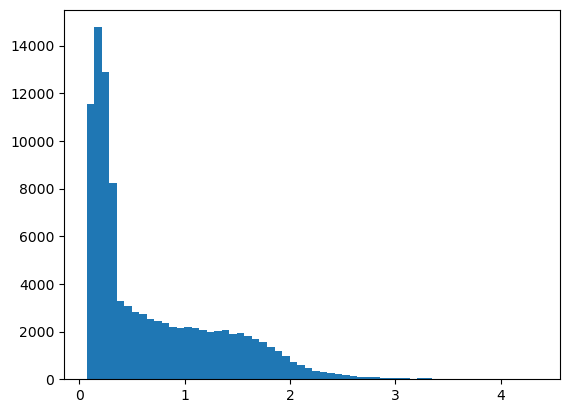

In [120]:
plt.hist(df_d['RMSE_psi_stem'], bins =60);

In [125]:
df_psi_stem = df_d.loc[df_d['RMSE_psi_stem'] < 0.076]
print(df_psi_stem.shape)

(91, 52)


In [122]:
df_J= df_d.loc[df_d['RMSE_J'] < 0.000235]
print(df_J.shape)

(92, 52)


Text(0.5, 1.0, 'pore_0')

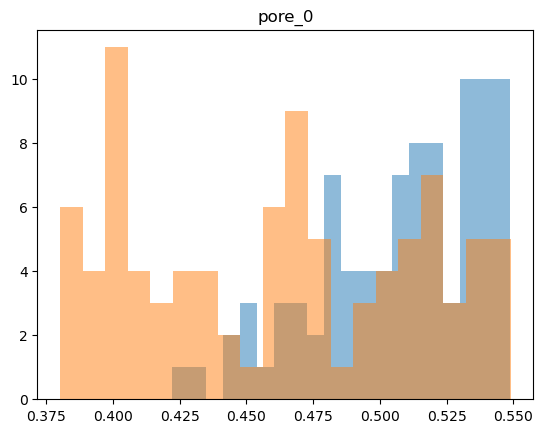

In [126]:
plt.hist(df_psi_stem['pore_0'], alpha = 0.5, bins = 20);
plt.hist(df_J['pore_0'], alpha = 0.5, bins = 20);
plt.title("pore_0")

In [127]:
vars = ['psi_leaf_50_close', 'd_50_close','stem_hydraulic_capacitance', 'k_xylem_sat','huber_value',  'leaf_hydraulic_capacitance', 'psi50_xylem','leaf_area_index', 'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0','jackson_root_beta', 'theta_s0', 'pore_0', 'theta_r0', 'anet_max', 'root_area_index', 'tree_density' ]

for var in vars:
    
    if var == 'leaf_hydraulic_capacitance':
        plt.hist(np.log10(df_psi_stem[var]), alpha = 0.5, bins = 20);
        plt.hist(np.log10(df_J[var]), alpha = 0.5, bins = 20);
    elif var == 'k_soil_sat0':
        plt.hist(np.log10(df_psi_stem[var]), alpha = 0.5, bins = 20);
        plt.hist(np.log10(df_J[var]), alpha = 0.5, bins = 20);
    else:
        plt.hist(df_psi_stem[var], alpha = 0.5, bins = 20);
        plt.hist(df_J[var], alpha = 0.5, bins = 20);

    plt.title(var)
    plt.savefig(f"{post_path}/hist_{var}.png")
    plt.close()

In [98]:
df_psi_stem

,Unnamed: 0,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,anet_max,sw_rad_max,...,solver_precision,psi_soil_sat0,k_soil_sat0,theta_s0,theta_r0,pore_0,RMSE_J,RMSE_G,RMSE_psi_stem,RMSE_com_avg
5931,5931,5931,1800.0,1800,False,1.0,4.0,Weibull,2.846080,972.935,...,1.000000e-10,-0.824945,2.993509e-07,0.485910,0.044916,0.433089,0.000329,0.000404,0.071698,1.010866
6875,6875,6875,1800.0,1800,False,1.0,4.0,Weibull,2.740750,972.935,...,1.000000e-10,-0.054400,1.268578e-06,0.489729,0.046663,0.388302,0.000335,0.000358,0.070786,1.012593
8314,8314,8314,1800.0,1800,False,1.0,4.0,Weibull,2.409196,972.935,...,1.000000e-10,-0.059487,6.835736e-07,0.497075,0.051577,0.416449,0.000303,0.000366,0.069133,0.953398
10152,10152,10152,1800.0,1800,False,1.0,4.0,Weibull,2.129192,972.935,...,1.000000e-10,-0.164902,5.739508e-07,0.486817,0.051351,0.404532,0.000330,0.000405,0.070787,1.004730
11035,11035,11035,1800.0,1800,False,1.0,4.0,Weibull,1.955522,972.935,...,1.000000e-10,-0.035750,3.221908e-07,0.471680,0.048045,0.436468,0.000349,0.000434,0.070083,1.027411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92857,92857,92857,1800.0,1800,False,1.0,4.0,Weibull,2.181599,972.935,...,1.000000e-10,-0.342450,8.846761e-07,0.490335,0.040226,0.408554,0.000363,0.000437,0.069393,1.041828
94450,94450,94450,1800.0,1800,False,1.0,4.0,Weibull,1.673477,972.935,...,1.000000e-10,-0.259025,4.036463e-07,0.471220,0.046057,0.426379,0.000322,0.000351,0.071207,0.997273
94975,94975,94975,1800.0,1800,False,1.0,4.0,Weibull,3.202938,972.935,...,1.000000e-10,-0.059179,4.065855e-07,0.475044,0.043988,0.396439,0.000290,0.000352,0.070685,0.946404
96287,96287,96287,1800.0,1800,False,1.0,4.0,Weibull,1.836043,972.935,...,1.000000e-10,-0.223389,9.822064e-07,0.492105,0.040817,0.414887,0.000333,0.000373,0.067432,0.984285


In [128]:
best_common = np.intersect1d(df_psi_stem.index, df_J.index)

In [129]:
df_best_c  = df_d.iloc[best_common]
df_best_c

,Unnamed: 0,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,anet_max,sw_rad_max,...,solver_precision,psi_soil_sat0,k_soil_sat0,theta_s0,theta_r0,pore_0,RMSE_J,RMSE_G,RMSE_psi_stem,RMSE_com_avg


In [130]:
df_d

,Unnamed: 0,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,anet_max,sw_rad_max,...,solver_precision,psi_soil_sat0,k_soil_sat0,theta_s0,theta_r0,pore_0,RMSE_J,RMSE_G,RMSE_psi_stem,RMSE_com_avg
0,0,0,1800.0,1800,False,1.0,4.0,Weibull,1.893146,972.935,...,1.000000e-10,-0.000323,5.807371e-07,0.492818,0.100516,0.498997,0.000359,0.000361,0.109215,1.334099
1,1,1,1800.0,1800,False,1.0,4.0,Weibull,2.303272,972.935,...,1.000000e-10,-0.001981,1.602408e-07,0.494667,0.082363,0.462612,0.000722,0.000621,0.921415,7.937622
2,2,2,1800.0,1800,False,1.0,4.0,Weibull,2.131615,972.935,...,1.000000e-10,-0.001550,2.831811e-07,0.479584,0.141517,0.528342,0.000737,0.000699,0.970071,8.322666
3,3,3,1800.0,1800,False,1.0,4.0,Weibull,1.247734,972.935,...,1.000000e-10,-0.000720,1.634312e-06,0.495013,0.130561,0.491854,0.000354,0.000369,0.116141,1.379973
4,4,4,1800.0,1800,False,1.0,4.0,Weibull,1.738465,972.935,...,1.000000e-10,-0.001986,2.253623e-07,0.488645,0.106303,0.539522,0.000389,0.000421,0.269997,2.581628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,99995,1800.0,1800,False,1.0,4.0,Weibull,2.104986,972.935,...,1.000000e-10,-0.001451,2.648069e-06,0.487403,0.130884,0.458451,0.000453,0.000464,0.104996,1.438491
99996,99996,99996,1800.0,1800,False,1.0,4.0,Weibull,1.893951,972.935,...,1.000000e-10,-0.001616,4.851705e-07,0.497269,0.145656,0.514857,0.000321,0.000450,0.636786,5.229326
99997,99997,99997,1800.0,1800,False,1.0,4.0,Weibull,3.571774,972.935,...,1.000000e-10,-0.000857,5.599295e-07,0.471732,0.133438,0.515859,0.001180,0.001085,0.481454,5.303939
99998,99998,99998,1800.0,1800,False,1.0,4.0,Weibull,1.675992,972.935,...,1.000000e-10,-0.001386,1.179810e-06,0.486322,0.121966,0.547241,0.000320,0.000346,0.174798,1.769957


In [131]:
m = 0.9570685625076294

In [132]:
df_best_psi_stem = df_d.sort_values(by='RMSE_psi_stem').iloc[0:30]
df_best_psi_stem.to_csv(f"{input_path}/parameters_best_psi_stem.csv")
df_best_J = df_d.sort_values(by='RMSE_J').iloc[0:30]
df_best_J.to_csv(f"{input_path}/parameters_best_J.csv")
df_best_both = df_d.sort_values(by='RMSE_com_avg').iloc[0:30]
df_best_both.to_csv(f"{input_path}/parameters_best_both.csv")


In [139]:
df_best_both.iloc[5]

Unnamed: 0                                                             91804
id                                                                     91804
dts                                                                   1800.0
dts_input                                                               1800
verbose                                                                False
max_psi_leaf_change_per_hour                                             1.0
minimum_psi_leaf_multiplier                                              4.0
conductivity_fraction_type                                           Weibull
anet_max                                                            1.298072
sw_rad_max                                                           972.935
sustain_xylem_damage                                                   False
root_area_index                                                     9.667883
canopy_height                                                             31

In [109]:
df_best_both.describe()

,Unnamed: 0,id,dts,dts_input,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,anet_max,sw_rad_max,root_area_index,canopy_height,...,solver_precision,psi_soil_sat0,k_soil_sat0,theta_s0,theta_r0,pore_0,RMSE_J,RMSE_G,RMSE_psi_stem,RMSE_com_avg
count,30.000000,30.000000,30.0,30.0,30.0,30.0,30.000000,3.000000e+01,30.000000,30.0,...,3.000000e+01,30.000000,3.000000e+01,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,50135.700000,50135.700000,1800.0,1800.0,1.0,4.0,1.712195,9.729350e+02,8.034165,31.0,...,1.000000e-10,-0.286583,7.231629e-07,0.482850,0.051831,0.410179,0.000264,0.000330,0.073036,0.926715
std,27649.272323,27649.272323,0.0,0.0,0.0,0.0,0.574156,3.468910e-13,3.659434,0.0,...,3.943694e-26,0.222160,4.895017e-07,0.007817,0.009225,0.023008,0.000017,0.000018,0.003586,0.015589
min,5541.000000,5541.000000,1800.0,1800.0,1.0,4.0,1.071543,9.729350e+02,2.167414,31.0,...,1.000000e-10,-0.709239,2.012533e-07,0.470465,0.040067,0.354361,0.000222,0.000286,0.067940,0.898660
25%,30735.750000,30735.750000,1800.0,1800.0,1.0,4.0,1.293754,9.729350e+02,4.643323,31.0,...,1.000000e-10,-0.456465,3.976120e-07,0.476606,0.044739,0.397997,0.000254,0.000318,0.070166,0.913384
50%,54501.000000,54501.000000,1800.0,1800.0,1.0,4.0,1.607239,9.729350e+02,8.106811,31.0,...,1.000000e-10,-0.251161,5.764187e-07,0.482340,0.050506,0.410872,0.000266,0.000328,0.072544,0.929090
75%,72699.000000,72699.000000,1800.0,1800.0,1.0,4.0,1.947215,9.729350e+02,11.113050,31.0,...,1.000000e-10,-0.092866,7.866837e-07,0.489169,0.058057,0.430203,0.000275,0.000340,0.074725,0.942444
max,93033.000000,93033.000000,1800.0,1800.0,1.0,4.0,3.089179,9.729350e+02,13.951427,31.0,...,1.000000e-10,-0.006787,2.092260e-06,0.498777,0.072093,0.447267,0.000293,0.000374,0.083458,0.946395


In [74]:
df_best_c

,Unnamed: 0,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,anet_max,sw_rad_max,...,solver_precision,psi_soil_sat0,k_soil_sat0,theta_s0,theta_r0,pore_0,RMSE_J,RMSE_G,RMSE_psi_stem,RMSE_com_avg


In [75]:
df_d.iloc[83165]

Unnamed: 0                                                             83165
id                                                                     83165
dts                                                                   1800.0
dts_input                                                               1800
verbose                                                                False
max_psi_leaf_change_per_hour                                             1.0
minimum_psi_leaf_multiplier                                              4.0
conductivity_fraction_type                                           Weibull
anet_max                                                             3.34912
sw_rad_max                                                           972.935
sustain_xylem_damage                                                   False
root_area_index                                                     2.300564
canopy_height                                                             31